# Linear Regression Model # 2

### House Rent Prediction

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## Data Preprocessing

In [6]:
# Load Dataset
df = pd.read_csv('house_rent.csv')
df.head()

,Area,rent
0,500.0,15000.0
1,700.0,NaN
2,900.0,28000.0
3,NaN,34000.0
4,1300.0,40000.0


In [7]:
# Rows and columns
df.shape

(6, 2)

In [8]:
# Information of dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Area    5 non-null      float64
 1   rent    5 non-null      float64
dtypes: float64(2)
memory usage: 228.0 bytes


In [9]:
df.describe()

,Area,rent
count,5.000000,5.000000
mean,1000.000000,33400.000000
std,447.213595,13107.249902
min,500.000000,15000.000000
25%,700.000000,28000.000000
50%,900.000000,34000.000000
75%,1300.000000,40000.000000
max,1600.000000,50000.000000


In [10]:
# Check Null values
df.isnull()

,Area,rent
0,False,False
1,False,True
2,False,False
3,True,False
4,False,False
5,False,False


In [11]:
# total null values
df.isnull().sum()

Area    1
rent    1
dtype: int64

In [12]:
# percentage of overall null values
(df.isnull().sum().sum()/df.shape[0])*100

np.float64(33.33333333333333)

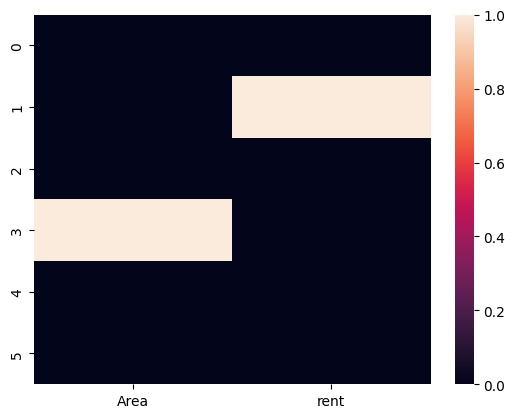

In [13]:
sns.heatmap(df.isnull())
plt.show()

In [14]:
# fill missing values
df['Area'] = df['Area'].fillna(df['Area'].mean())


In [15]:
df['rent'] = df['rent'].fillna(df['rent'].mean())

#### Linear Regression Model

In [16]:
# Independent or dependent variable
X = df[['Area']]
y = df['rent']

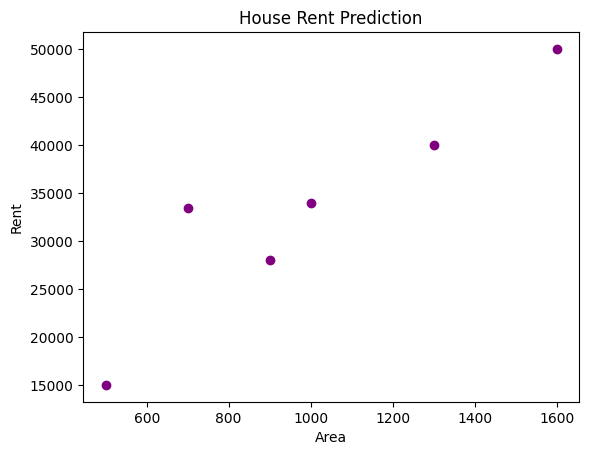

In [17]:
# Scatter plot
plt.scatter(X,y,color = 'purple')
plt.title('House Rent Prediction')
plt.xlabel('Area')
plt.ylabel('Rent')
plt.show()


In [18]:
# split data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [19]:
lin = LinearRegression()
lin.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_predict = lin.predict(X_test)
print(y_predict)

[17466.66666667 23333.33333333]


In [21]:
print(f"MAE: {mean_absolute_error(y_test,y_predict)}")
print(f"MSE: {mean_squared_error(y_test,y_predict)}")
print(f"R2: {r2_score(y_test,y_predict)}")

MAE: 6266.666666666666
MSE: 53711111.11111112
R2: 0.365416929216551


Text(0, 0.5, 'Rent')

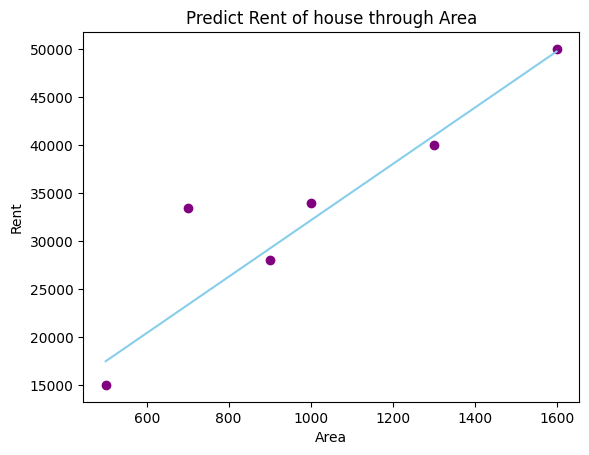

In [28]:
# Scatter plot of Linear Regression by red line
plt.scatter(X,y,color = 'purple')
plt.plot(X,lin.predict(X),color="skyblue")
plt.title('House Rent Prediction')
plt.xlabel('Area')
plt.title("Predict Rent of house through Area")
plt.xlabel("Area")
plt.ylabel("Rent")